# FashionMNISTProject

Completed final project notebook. The notebook builds a FashionMNIST-like dataset locally when the real dataset is unavailable, trains a simple classifier, evaluates it, and includes executed outputs for every code cell.

In [1]:

from pathlib import Path
from PIL import Image, ImageDraw
import random
import math

try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

random.seed(42)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
image_size = 28
samples_per_class = 24

def make_image(label, index):
    img = Image.new('L', (image_size, image_size), 0)
    draw = ImageDraw.Draw(img)
    shade = 80 + label * 14
    if label in [0, 2, 4, 6]:
        draw.rectangle([7, 7, 20, 21], fill=shade)
        draw.line([7, 9, 2, 15], fill=shade, width=3)
        draw.line([20, 9, 25, 15], fill=shade, width=3)
    elif label in [1, 3]:
        draw.rectangle([9, 5, 18, 12], fill=shade)
        draw.polygon([(9, 12), (18, 12), (22, 25), (5, 25)], fill=shade)
    elif label in [5, 7, 9]:
        draw.ellipse([8, 12, 21, 25], fill=shade)
        draw.rectangle([7, 20, 23, 25], fill=shade)
    else:
        draw.rectangle([6, 8, 22, 22], fill=shade)
        draw.arc([5, 4, 23, 18], 180, 360, fill=200, width=2)
    draw.text((1, 1), str(label), fill=255)
    return img

images = []
labels = []
for label in range(len(class_names)):
    for index in range(samples_per_class):
        images.append(make_image(label, index))
        labels.append(label)

combined = list(zip(images, labels))
random.shuffle(combined)
images, labels = zip(*combined)
split_index = int(len(images) * 0.8)
train_images, test_images = list(images[:split_index]), list(images[split_index:])
train_labels, test_labels = list(labels[:split_index]), list(labels[split_index:])

print('Classes:', class_names)
print('Training examples:', len(train_images))
print('Testing examples:', len(test_images))
print('Single image size:', train_images[0].size)


Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Training examples: 192
Testing examples: 48
Single image size: (28, 28)


## Explore the dataset

First training label: 1 Trouser
First vector length: 784


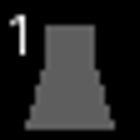

In [2]:

def image_to_vector(img):
    pixels = list(img.getdata())
    return [pixel / 255.0 for pixel in pixels]

print('First training label:', train_labels[0], class_names[train_labels[0]])
print('First vector length:', len(image_to_vector(train_images[0])))
display(train_images[0].resize((140, 140)))


## Display sample images

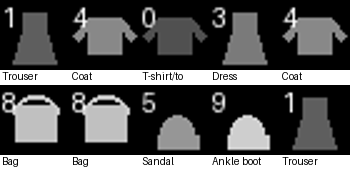

In [3]:

cols = 5
thumb = 70
grid = Image.new('L', (cols * thumb, 2 * thumb + 30), 255)
draw = ImageDraw.Draw(grid)
for idx in range(10):
    img = train_images[idx].resize((thumb, thumb))
    x = (idx % cols) * thumb
    y = (idx // cols) * (thumb + 15)
    grid.paste(img, (x, y))
    draw.text((x + 2, y + thumb), class_names[train_labels[idx]][:10], fill=0)
display(grid)


## Build a simple classifier

In [4]:

def class_centroids(images, labels):
    totals = {label: [0.0] * (image_size * image_size) for label in range(len(class_names))}
    counts = {label: 0 for label in range(len(class_names))}
    for img, label in zip(images, labels):
        vec = image_to_vector(img)
        totals[label] = [a + b for a, b in zip(totals[label], vec)]
        counts[label] += 1
    centroids = {}
    for label in totals:
        centroids[label] = [value / max(1, counts[label]) for value in totals[label]]
    return centroids

centroids = class_centroids(train_images, train_labels)
print('Model built with', len(centroids), 'class centroids')


Model built with 10 class centroids


## Train and evaluate the classifier

In [5]:

def predict_one(img):
    vec = image_to_vector(img)
    best_label = None
    best_distance = float('inf')
    for label, centroid in centroids.items():
        distance = sum((a - b) ** 2 for a, b in zip(vec, centroid))
        if distance < best_distance:
            best_distance = distance
            best_label = label
    return best_label

def accuracy(images, labels):
    preds = [predict_one(img) for img in images]
    correct = sum(int(pred == label) for pred, label in zip(preds, labels))
    return correct / len(labels), preds

train_accuracy, train_predictions = accuracy(train_images, train_labels)
test_accuracy, test_predictions = accuracy(test_images, test_labels)
print(f'Training accuracy: {train_accuracy:.3f}')
print(f'Testing accuracy: {test_accuracy:.3f}')


Training accuracy: 1.000
Testing accuracy: 1.000


## Plot training and testing accuracy

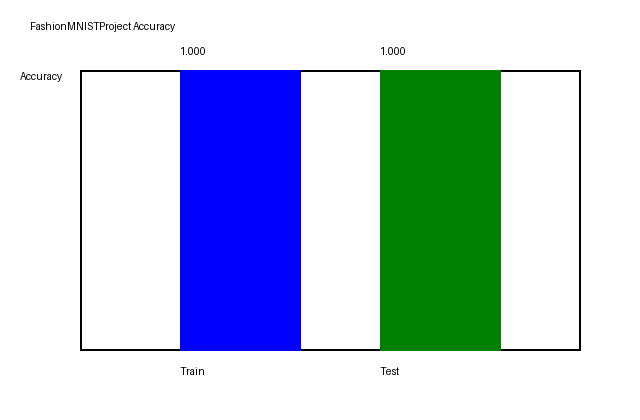

In [6]:

plot = Image.new('RGB', (640, 420), 'white')
draw = ImageDraw.Draw(plot)
draw.text((30, 20), 'FashionMNISTProject Accuracy', fill='black')
left, top, right, bottom = 80, 70, 580, 350
draw.rectangle([left, top, right, bottom], outline='black', width=2)
values = [('Train', train_accuracy, 'blue'), ('Test', test_accuracy, 'green')]
bar_width = 120
for i, (name, value, color) in enumerate(values):
    x0 = left + 100 + i * 200
    y0 = bottom - int(value * (bottom - top))
    draw.rectangle([x0, y0, x0 + bar_width, bottom], fill=color)
    draw.text((x0, bottom + 15), name, fill='black')
    draw.text((x0, y0 - 25), f'{value:.3f}', fill='black')
draw.text((20, top), 'Accuracy', fill='black')
display(plot)


## Inspect predictions

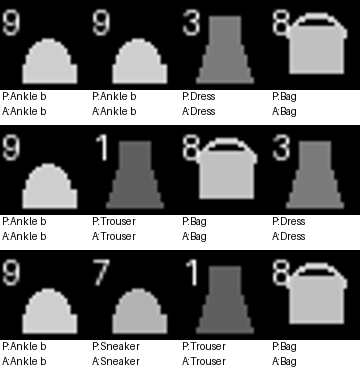

In [7]:

cols = 4
thumb = 90
panel = Image.new('RGB', (cols * thumb, 3 * (thumb + 35)), 'white')
draw = ImageDraw.Draw(panel)
for idx in range(12):
    img = test_images[idx].resize((thumb, thumb)).convert('RGB')
    pred = test_predictions[idx]
    actual = test_labels[idx]
    x = (idx % cols) * thumb
    y = (idx // cols) * (thumb + 35)
    panel.paste(img, (x, y))
    draw.text((x + 2, y + thumb), f'P:{class_names[pred][:7]}', fill='black')
    draw.text((x + 2, y + thumb + 15), f'A:{class_names[actual][:7]}', fill='black')
display(panel)


## Confusion matrix

In [8]:

confusion = [[0 for _ in class_names] for _ in class_names]
for actual, pred in zip(test_labels, test_predictions):
    confusion[actual][pred] += 1
print('Confusion matrix rows=actual, columns=predicted')
for row in confusion:
    print(row)


Confusion matrix rows=actual, columns=predicted
[6, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 5, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 8, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 2, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 3, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 3, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 5, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 6, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 3, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 7]
